In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv('/content/creditcard.csv')

In [23]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
df.shape

(284807, 31)

In [25]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [26]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


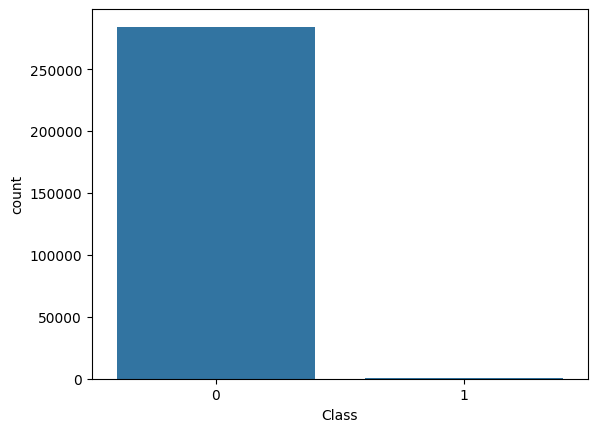

In [27]:
sns.countplot(x='Class', data=df)
plt.show()

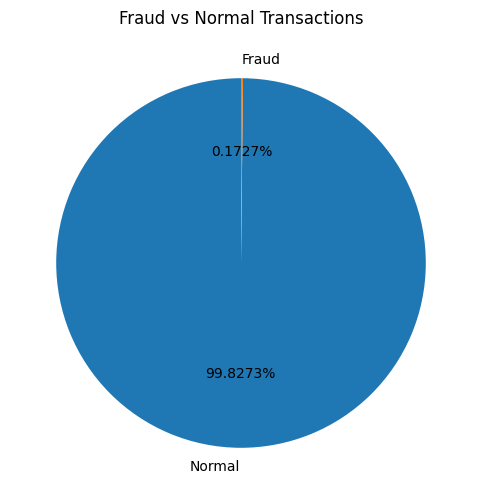

In [64]:

fraud_count = df['Class'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    fraud_count,
    labels=['Normal', 'Fraud'],
    autopct='%1.4f%%',
    startangle=90
)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [29]:
X = df.drop('Class', axis=1)
y = df['Class']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [31]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [35]:
df = df.dropna()

In [36]:
print(df.shape)
print(df.tail(10))

(284807, 31)
            Time         V1         V2        V3        V4        V5  \
284797  1.641847  -0.241923   0.712247  0.399806 -0.463406  0.244531   
284798  1.641847   0.219529   0.881246 -0.635891  0.960928 -0.152971   
284799  1.641868  -1.775135  -0.004235  1.189786  0.331096  1.196063   
284800  1.641889   2.039560  -0.175233 -1.196825  0.234580 -0.008713   
284801  1.641910   0.120316   0.931005 -0.546012 -0.745097  1.130314   
284802  1.641931 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  1.641952  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  1.641974   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  1.641974  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  1.642058  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
284797 -1.343668  0.929369 -0.206210  0.106234  ... -0.228876 -0.514376   
284798 -1.014307  0.427126  0.121340 -0.2856

In [37]:
print(df.shape)
print(df['Class'].isnull().sum())
print(df['Class'].unique())

(284807, 31)
0
[0 1]


In [44]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9995611109160493


In [51]:
y_pred = model.predict(X_test)
print("Predictions for the first 5 test samples:", y_pred[:5])

Predictions for the first 5 test samples: [1 0 0 0 0]


In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



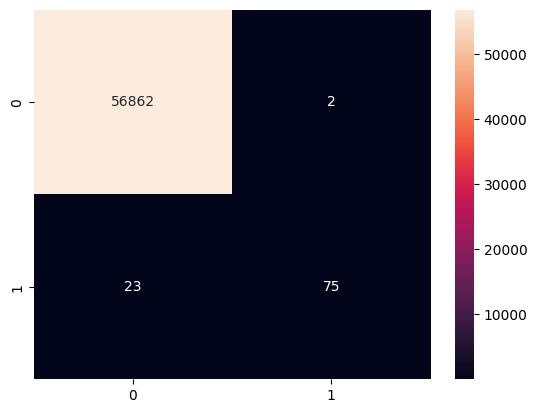

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

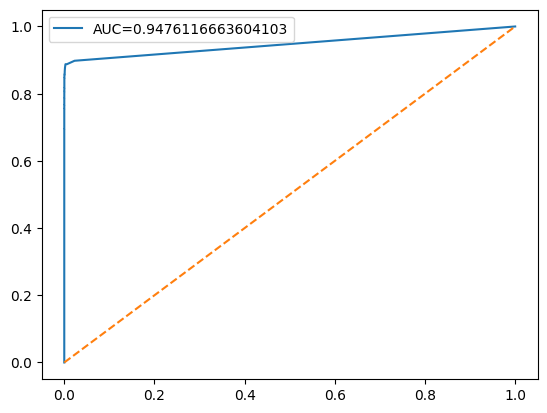

In [ ]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

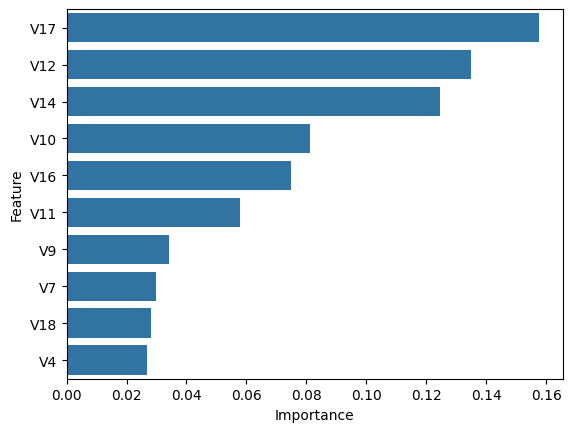

In [ ]:
importance = model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})
feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)
sns.barplot(
    x=feature_df['Importance'][:10],
    y=feature_df['Feature'][:10]
)
plt.show()